In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("../")
from diabnet.apply_ensemble import Predictor
from diabnet.data import get_feature_names
from diabnet.ensemble import Ensemble

In [6]:
e = Ensemble('../diabnet/models/model-5-soft-label-age-positives-2500-dropout0-bn-decay-flood-hyperopt-batch256-lc2')

../diabnet/models/model-5-soft-label-age-positives-2500-dropout0-bn-decay-flood-hyperopt-batch256-lc2


In [7]:
len(e.models)

100

In [8]:
c = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)

In [9]:
c[990:]

['snp_9_68692515',
 'snp_12_53198338',
 'snp_6_37571581',
 'snp_20_52032232',
 'snp_20_52032233',
 'snp_20_26104019',
 'snp_20_50189624',
 'snp_1_143276644',
 'snp_16_9536673',
 'snp_20_25734788',
 'AGE',
 'sex',
 'mo_t2d',
 'fa_t2d']

In [10]:
pred = Predictor(e, c, "../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv")

NEGATIVE FILE ../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv


In [11]:
df = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")
id = 2
features = df[c].iloc[id].values
label = df["T2D"].iloc[id]

In [12]:
info = ["AGE", "T2D"]
df[info].iloc[id]

AGE    52
T2D     1
Name: 2, dtype: int64

In [13]:
probs = pred.patient(features, age=60, samples_per_model=1)
neg = pred.negatives(age=60)
np.random.shuffle(neg)

In [36]:
probs = pred.patient(features, age=60, samples_per_model=1)

In [37]:
probs

array([0.3467931 , 0.3898247 , 0.35830283, 0.58578837, 0.37653476,
       0.3163125 , 0.49247557, 0.2626593 , 0.36165228, 0.66782343,
       0.40317085, 0.3652743 , 0.4777031 , 0.44455412, 0.29557884,
       0.4587358 , 0.5024613 , 0.5484702 , 0.45205736, 0.49035597,
       0.34897843, 0.37549055, 0.3114506 , 0.33213118, 0.42646736,
       0.2610889 , 0.37446502, 0.35974255, 0.5574134 , 0.3338083 ,
       0.48190427, 0.3588285 , 0.4781188 , 0.45689237, 0.3676279 ,
       0.33852607, 0.3286591 , 0.49334005, 0.49008217, 0.26233488,
       0.22763845, 0.45865524, 0.24522008, 0.44682992, 0.3192165 ,
       0.38993183, 0.48187116, 0.3548557 , 0.21354818, 0.3683079 ,
       0.3673334 , 0.38867104, 0.14998654, 0.2620193 , 0.42513698,
       0.30783767, 0.38182116, 0.5021534 , 0.52740425, 0.6001504 ,
       0.4459311 , 0.48138085, 0.37971276, 0.4226515 , 0.596207  ,
       0.28468743, 0.3278784 , 0.37745824, 0.45164087, 0.48630738,
       0.4781041 , 0.27213746, 0.37893397, 0.35862193, 0.19186

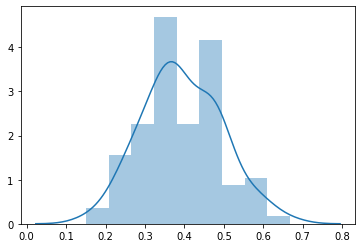

In [38]:
sns.distplot(probs)

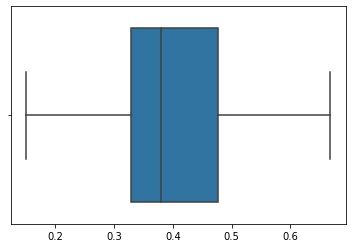

In [39]:
sns.boxplot(probs)

In [14]:
em = np.split(probs, 100)
em

[array([0.9096985], dtype=float32),
 array([0.3898349], dtype=float32),
 array([0.9033304], dtype=float32),
 array([0.8183117], dtype=float32),
 array([0.63487744], dtype=float32),
 array([0.9737917], dtype=float32),
 array([0.8128226], dtype=float32),
 array([0.97957957], dtype=float32),
 array([0.8149596], dtype=float32),
 array([0.93464476], dtype=float32),
 array([0.9399246], dtype=float32),
 array([0.87073195], dtype=float32),
 array([0.89149964], dtype=float32),
 array([0.8667154], dtype=float32),
 array([0.7964591], dtype=float32),
 array([0.8607293], dtype=float32),
 array([0.7648434], dtype=float32),
 array([0.90658027], dtype=float32),
 array([0.6178535], dtype=float32),
 array([0.92657155], dtype=float32),
 array([0.93558955], dtype=float32),
 array([0.9800948], dtype=float32),
 array([0.9893428], dtype=float32),
 array([0.88247585], dtype=float32),
 array([0.8351702], dtype=float32),
 array([0.88982785], dtype=float32),
 array([0.82329816], dtype=float32),
 array([0.7649640

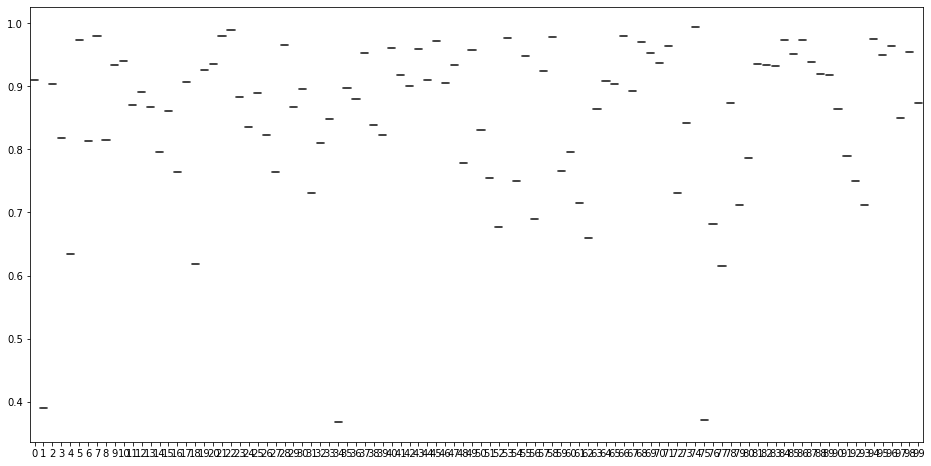

In [15]:
plt.figure(figsize=(16,8))

sns.boxplot(x=np.arange(100),y=em)

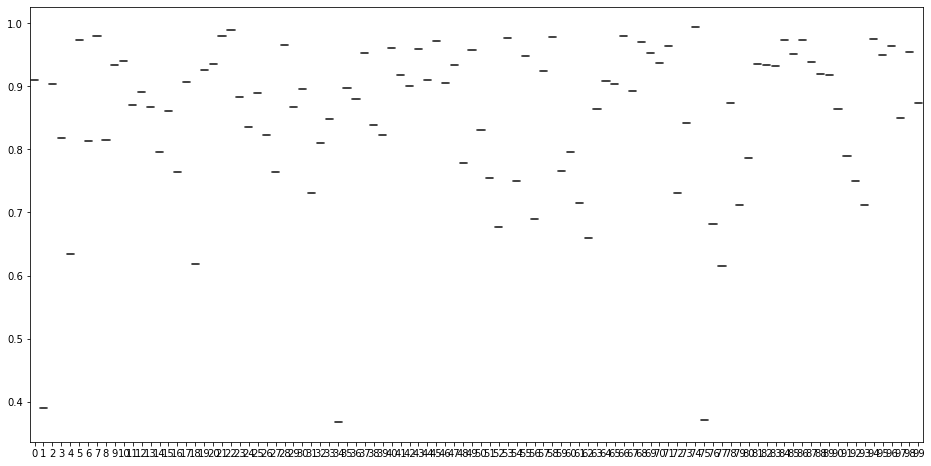

In [16]:
plt.figure(figsize=(16,8))

sns.boxplot(x=np.arange(100),y=em)

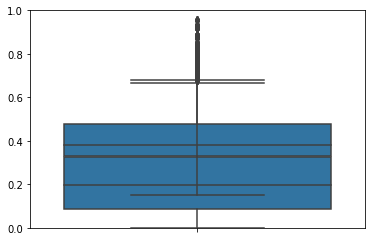

In [40]:
sns.boxplot(y=neg)
sns.boxplot(y=probs)
plt.ylim(0,1);

In [29]:
sns.boxplot(x=['patient', 'negatives\n(age >= 60)'], y= [probs[:10000], neg[:10000]])
plt.ylim(0,1);

ValueError: Neither the `x` nor `y` variable appears to be numeric.

In [20]:
neg_life = pred.negatives_life(samples_per_model=1)

In [41]:
probs_life = pred.patient_life(features, samples_per_model=1)

In [1]:
plt.figure(figsize=(16,8))
plt.subplot(121)

sns.boxplot(x=[i for i in probs_life[1]], y=probs_life[0], showfliers=False);
plt.xlabel("patient")
plt.ylim(0,1);
plt.subplot(122)
sns.boxplot(x=[i for i in neg_life[1]], y=neg_life[0], showfliers=False);
plt.xlabel("negatives\n(age >= 60)")
plt.ylim(0,1);
plt.savefig("negative-lifetime-boxplots.png")

NameError: name 'plt' is not defined

In [23]:
df[["id","AGE", "mo_t2d","fa_t2d", "T2D", "mo", "fa"]]

,id,AGE,mo_t2d,fa_t2d,T2D,mo,fa
0,A11123,51,2.0,2.0,1,0,0
1,A00551,40,0.0,1.0,0,A00548,A00547
2,A02267,52,0.0,2.0,1,A02254,A20031
3,A00586,34,0.0,1.0,0,A00300,A00585
4,A16039,37,1.0,1.0,0,A02064,A02063
...,...,...,...,...,...,...,...
545,A02889,36,1.0,0.0,0,A02156,A02149
546,A26102,41,0.0,2.0,0,A01009,A26053
547,A03220,67,2.0,2.0,0,A23019,A23015
548,A39026,41,0.0,2.0,0,A39014,A39020


In [15]:
len(probs)

1000

In [16]:
len(neg)

89000